# 🎗️ GraphMammoNet (MammoGNN) Applied to RSNA Breast Cancer Detection

### 📌 Nghiên cứu tham chiếu & Mã nguồn gốc:
* **Paper:** *Edge detection and graph neural networks to classify mammograms: A case study with a dataset from Vietnamese patients* (Duong et al., Applied Soft Computing, 2022).
* **GitHub Repository:** [https://github.com/linhduongtuan/GraphMammoNet](https://github.com/linhduongtuan/GraphMammoNet)
* **Kaggle Dataset:** [RSNA Screening Mammography Breast Cancer Detection](https://www.kaggle.com/competitions/rsna-breast-cancer-detection/data)

---
### 🧠 Luồng kiến trúc GraphMammoNet áp dụng cho dữ liệu RSNA:
1. **DICOM Preprocessing:** Đọc ảnh X-quang tuyến vú 12/16-bit, hiệu chỉnh LUT/MONOCHROME và chuẩn hóa về 8-bit `[0, 255]`.
2. **Edge Transformation:** Trích xuất đường biên mô tuyến vú bằng toán tử **Prewitt filter (Prewitt_v2)** hoặc **Sobel/Canny** như nguyên bản GitHub.
3. **Graph Construction:**
   * Mỗi điểm ảnh biên có giá trị $\ge 128$ được xem là một **Node** (đỉnh).
   * Thuộc tính node: Giá trị độ sáng xám chuẩn hóa Z-score $(x - \mu) / \sigma$.
   * **Edges (Cạnh):** Kết nối không gian 8 lân cận (8-connectivity) giữa các pixel biên liền kề.
4. **Graph Neural Network (`GraphGNNModel`):**
   * Lớp tích chập đồ thị: Hỗ trợ `GraphConv`, `GCNConv`, hoặc `GATConv` (exact code từ `models.py`).
   * Global Graph Pooling: `pyg_nn.global_mean_pool` gom đặc trưng toàn bộ đồ thị.
   * Classification Head: Dropout + Linear phân loại nguy cơ ung thư (`cancer`: 0 hoặc 1).
5. **Xử lý Mất cân bằng dữ liệu (Imbalanced Data):** Áp dụng trọng số phạt `class_weights` tương ứng với tỷ lệ ~2.1% ca dương tính của RSNA.
6. **Kaggle Submission:** Gom cụm dự đoán theo từng bên vú `prediction_id = patient_id_laterality` và xuất file `submission.csv`.


In [1]:
# Cell 1: Cài đặt thư viện. KHÔNG nâng cấp pydicom tại đây (gây lỗi 'partially initialized module' do module cũ đã nằm trong bộ nhớ kernel)
!pip install -q torch_geometric
!pip install -q pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.5 MB/s eta 0:00:00


In [2]:
# Cell 2: Khai báo thư viện và cấu hình tham số
import os
import glob
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold

# Computer Vision & Medical DICOM
import cv2

def import_pydicom_safely():
    '''Import pydicom tự phục hồi: xóa module nửa vời trong bộ nhớ, nếu vẫn lỗi thì cài bản sạch vào thư mục riêng.'''
    import sys, subprocess, tempfile
    def _purge():
        for k in [k for k in sys.modules if k == 'pydicom' or k.startswith('pydicom.')]:
            del sys.modules[k]
    _purge()
    try:
        import pydicom.uid
        import pydicom
        return pydicom
    except Exception as e:
        print(f'[!] pydicom hệ thống bị lỗi ({e!r}) -> cài bản sạch vào thư mục riêng...')
        clean_dir = os.path.join(tempfile.gettempdir(), 'clean_pydicom')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--no-deps', '--upgrade',
                        '--target', clean_dir, 'pydicom==3.0.1'], check=False)
        sys.path.insert(0, clean_dir)
        _purge()
        import pydicom.uid
        import pydicom
        return pydicom

pydicom = import_pydicom_safely()
print('pydicom version:', pydicom.__version__, '| file:', pydicom.__file__)

# PyTorch & PyTorch Geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import torch_geometric.nn as pyg_nn
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, GCNConv, GraphConv

# Cấu hình tái lập kết quả (Reproducibility)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Môi trường chạy: {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"})')

# Đường dẫn dữ liệu chuẩn trên Kaggle
KAGGLE_DIR = '/kaggle/input/rsna-breast-cancer-detection'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)


pydicom version: 3.0.2 | file: /usr/local/lib/python3.13/dist-packages/pydicom/__init__.py
Môi trường chạy: cuda (Tesla T4)


## 📊 CELL EDA: Khám Phá & Phân Tích Dữ Liệu RSNA Breast Cancer Detection

Cell này thực hiện phân tích thống kê toàn diện:
1. **Tổng quan bảng dữ liệu `train.csv`:** Kích thước, kiểu dữ liệu, các trường khuyết thiếu.
2. **Tỷ lệ mất cân bằng nghiêm trọng:** Tỷ lệ nhãn `cancer` (Chỉ ~2.1% mẫu dương tính).
3. **Mối liên hệ giữa Mật độ mô vú (`density`) & BIRADS với Tỷ lệ Ung thư.**
4. **Phân bố Tư thế chụp (`view`: CC vs MLO) và Bên ngực (`laterality`: L vs R).**
5. **Phân bố Độ tuổi bệnh nhân (`age`) theo từng nhóm nhãn.**
6. **Trực quan hóa mẫu ảnh X-quang DICOM -> Lọc biên Prewitt -> Cấu trúc đồ thị Node/Edge của GraphMammoNet.**


Lưu ý: Không tìm thấy train.csv tại đường dẫn Kaggle. Đang tạo dữ liệu mẫu mô phỏng để chạy thử nghiệm.
               BÁO CÁO THỐNG KÊ EDA TẬP DỮ LIỆU RSNA
• Tổng số mẫu ảnh mammogram: 300
• Số bệnh nhân phân biệt:     300
• Số thuộc tính (cột):         11

• Phân bố nhãn mục tiêu [cancer]:
  - Nhãn 0 (Âm tính / Lành tính): 293 mẫu (97.67%)
  - Nhãn 1 (Dương tính / Ung thư): 7 mẫu (2.33%)
  ==> MỨC ĐỘ MẤT CÂN BẰNG: 1 ca ung thư trên mỗi ~42 ca bình thường!


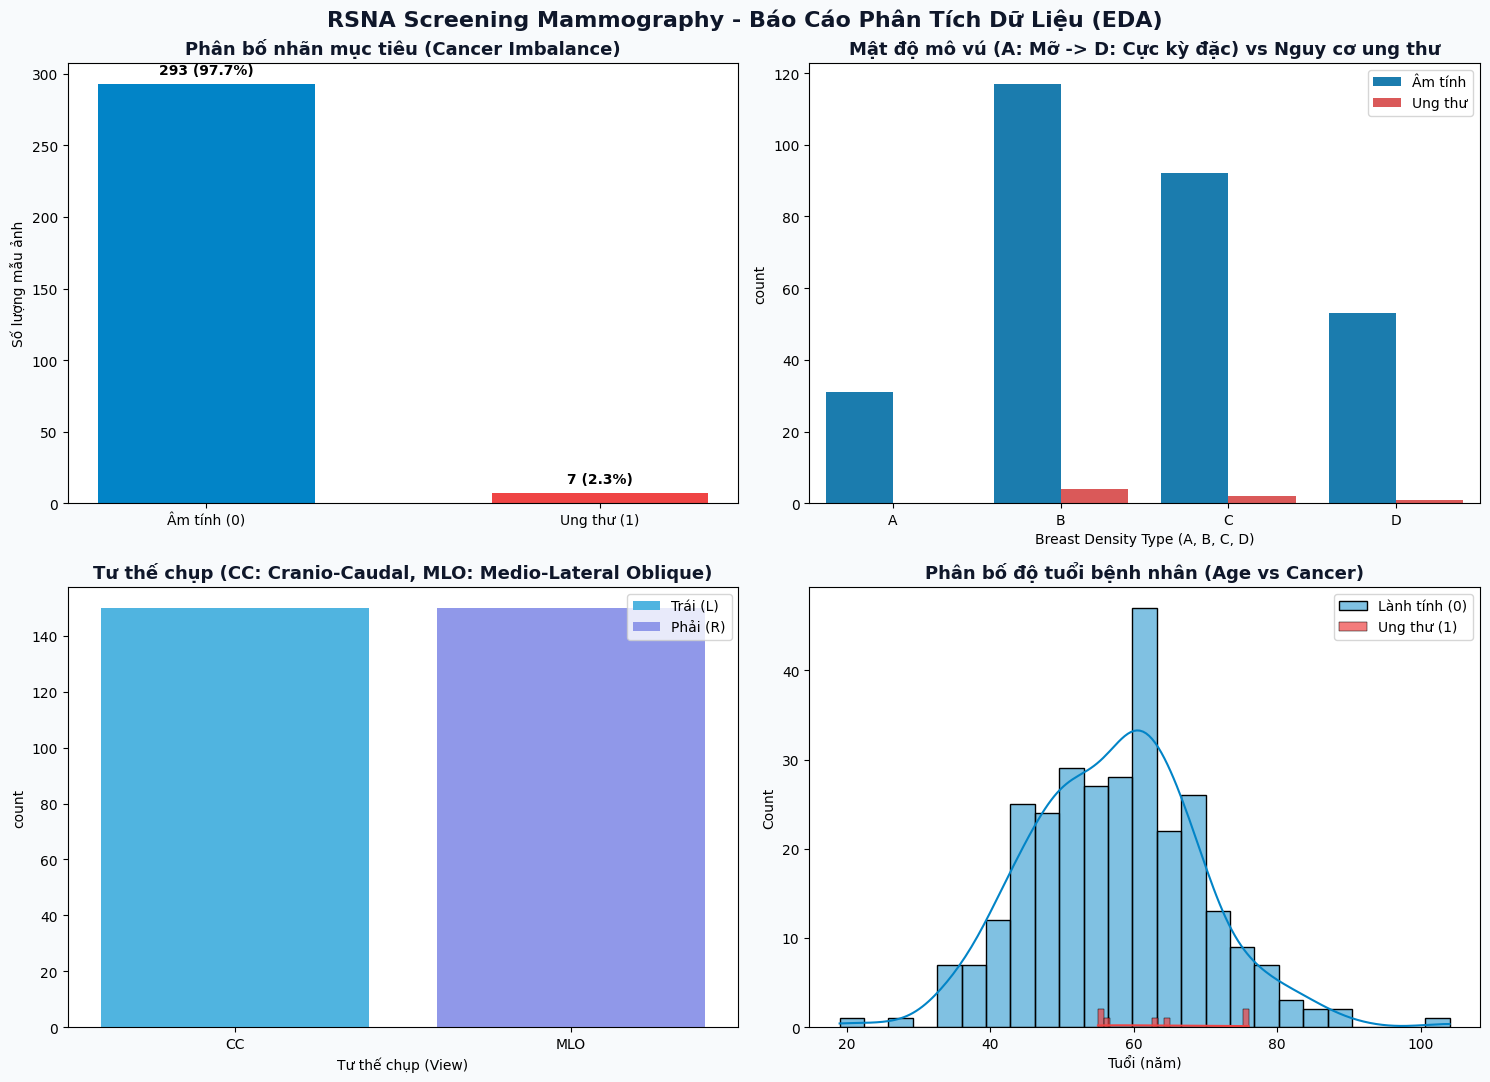


Trực quan hóa chuyển đổi đồ thị GraphMammoNet trên một mẫu ảnh:


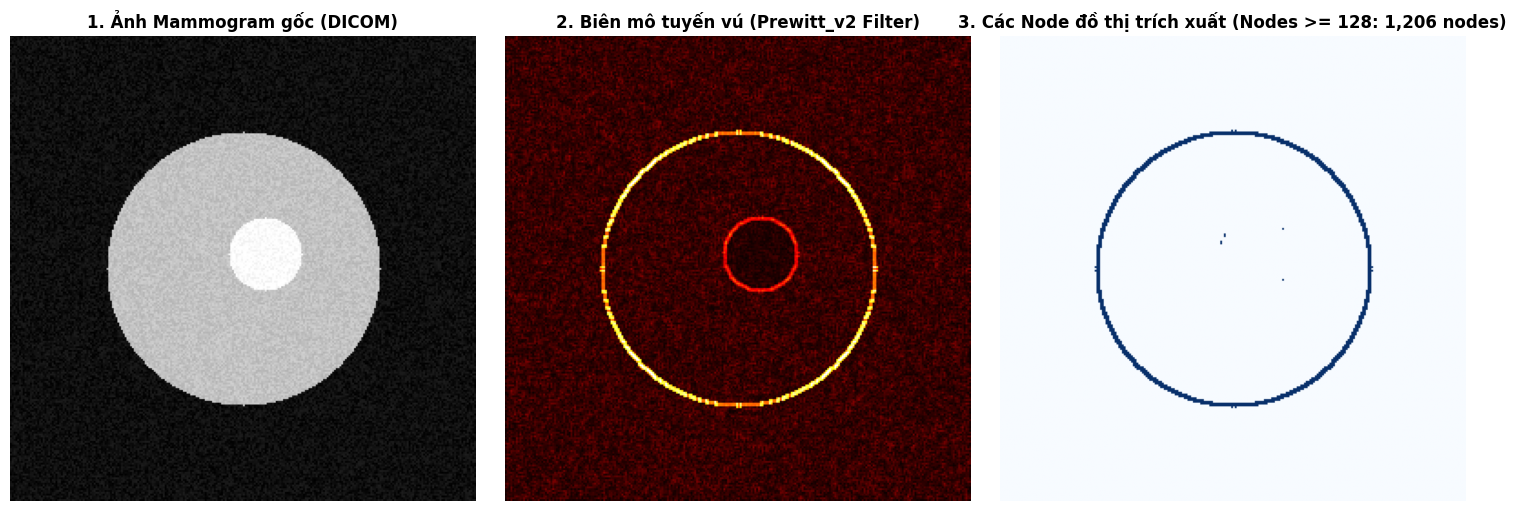

In [3]:
# Cell 3: EXPLORATORY DATA ANALYSIS (EDA CELL)
train_csv_path = os.path.join(KAGGLE_DIR, 'train.csv')

if os.path.exists(train_csv_path):
    df_train = pd.read_csv(train_csv_path)
else:
    print('Lưu ý: Không tìm thấy train.csv tại đường dẫn Kaggle. Đang tạo dữ liệu mẫu mô phỏng để chạy thử nghiệm.')
    df_train = pd.DataFrame({
        'site_id': [1]*150 + [2]*150,
        'patient_id': list(range(1001, 1301)),
        'image_id': list(range(2001, 2301)),
        'laterality': ['L', 'R']*150,
        'view': ['CC', 'MLO']*150,
        'age': np.random.normal(58, 12, 300).astype(int),
        'cancer': [1]*7 + [0]*293, # ~2.3% ca ung thư
        'biopsy': [1]*12 + [0]*288,
        'invasive': [1]*5 + [0]*295,
        'density': np.random.choice(['A', 'B', 'C', 'D'], 300, p=[0.1, 0.4, 0.35, 0.15]),
        'BIRADS': np.random.choice([0, 1, 2], 300, p=[0.1, 0.8, 0.1])
    })

print('='*70)
print('               BÁO CÁO THỐNG KÊ EDA TẬP DỮ LIỆU RSNA')
print('='*70)
print(f'• Tổng số mẫu ảnh mammogram: {df_train.shape[0]:,}')
print(f'• Số bệnh nhân phân biệt:     {df_train["patient_id"].nunique():,}')
print(f'• Số thuộc tính (cột):         {df_train.shape[1]}')

# 1. Thống kê nhãn mục tiêu cancer
cancer_counts = df_train['cancer'].value_counts()
cancer_pcts = df_train['cancer'].value_counts(normalize=True) * 100
print(f'\n• Phân bố nhãn mục tiêu [cancer]:')
print(f'  - Nhãn 0 (Âm tính / Lành tính): {cancer_counts.get(0, 0):,} mẫu ({cancer_pcts.get(0, 0):.2f}%)')
print(f'  - Nhãn 1 (Dương tính / Ung thư): {cancer_counts.get(1, 0):,} mẫu ({cancer_pcts.get(1, 0):.2f}%)')
print(f'  ==> MỨC ĐỘ MẤT CÂN BẰNG: 1 ca ung thư trên mỗi ~{int(round(cancer_counts.get(0, 0)/max(1, cancer_counts.get(1, 0))))} ca bình thường!')

# 2. Trực quan hóa bảng biểu đồ thống kê EDA 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.patch.set_facecolor('#F8FAFC')
plt.suptitle('RSNA Screening Mammography - Báo Cáo Phân Tích Dữ Liệu (EDA)', fontsize=16, fontweight='bold', color='#0F172A')

# Biểu đồ 1: Phân bố nhãn ung thư (Target Distribution)
ax1 = axes[0, 0]
bars = ax1.bar(['Âm tính (0)', 'Ung thư (1)'], [cancer_counts.get(0, 0), cancer_counts.get(1, 0)], color=['#0284C7', '#EF4444'], width=0.55)
ax1.set_title('Phân bố nhãn mục tiêu (Cancer Imbalance)', fontsize=13, fontweight='bold', color='#0F172A')
ax1.set_ylabel('Số lượng mẫu ảnh')
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f'{int(yval):,} ({yval/len(df_train)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

# Biểu đồ 2: Mật độ mô tuyến vú (Density) vs Tỷ lệ ung thư
ax2 = axes[0, 1]
if 'density' in df_train.columns and df_train['density'].notnull().sum() > 0:
    density_order = ['A', 'B', 'C', 'D']
    dens_df = df_train.dropna(subset=['density'])
    sns.countplot(data=dens_df, x='density', hue='cancer', order=density_order, palette=['#0284C7', '#EF4444'], ax=ax2)
    ax2.set_title('Mật độ mô vú (A: Mỡ -> D: Cực kỳ đặc) vs Nguy cơ ung thư', fontsize=13, fontweight='bold', color='#0F172A')
    ax2.set_xlabel('Breast Density Type (A, B, C, D)')
    ax2.legend(['Âm tính', 'Ung thư'])
else:
    ax2.text(0.5, 0.5, 'Cột density không có sẵn', ha='center', va='center')

# Biểu đồ 3: Tư thế chụp (View) & Bên ngực (Laterality)
ax3 = axes[1, 0]
if 'view' in df_train.columns and 'laterality' in df_train.columns:
    sns.countplot(data=df_train, x='view', hue='laterality', palette=['#38BDF8', '#818CF8'], ax=ax3)
    ax3.set_title('Tư thế chụp (CC: Cranio-Caudal, MLO: Medio-Lateral Oblique)', fontsize=13, fontweight='bold', color='#0F172A')
    ax3.set_xlabel('Tư thế chụp (View)')
    ax3.legend(['Trái (L)', 'Phải (R)'])

# Biểu đồ 4: Phân bố độ tuổi (Age Distribution)
ax4 = axes[1, 1]
if 'age' in df_train.columns and df_train['age'].notnull().sum() > 0:
    sns.histplot(df_train[df_train['cancer'] == 0]['age'].dropna(), color='#0284C7', label='Lành tính (0)', kde=True, ax=ax4, bins=25, alpha=0.5)
    sns.histplot(df_train[df_train['cancer'] == 1]['age'].dropna(), color='#EF4444', label='Ung thư (1)', kde=True, ax=ax4, bins=25, alpha=0.7)
    ax4.set_title('Phân bố độ tuổi bệnh nhân (Age vs Cancer)', fontsize=13, fontweight='bold', color='#0F172A')
    ax4.set_xlabel('Tuổi (năm)')
    ax4.legend()

plt.tight_layout()
plt.show()

# 3. Trực quan hóa quy trình: Ảnh X-quang -> Lọc biên Prewitt -> Cấu trúc Node đồ thị GraphMammoNet
print('\nTrực quan hóa chuyển đổi đồ thị GraphMammoNet trên một mẫu ảnh:')
demo_img = np.zeros((256, 256), dtype=np.uint8)
cv2.circle(demo_img, (128, 128), 75, 180, -1)
cv2.circle(demo_img, (140, 120), 20, 240, -1) # Mô tổn thương tăng sinh
noise = np.random.randint(0, 30, (256, 256), dtype=np.uint8)
demo_img = cv2.add(demo_img, noise)

# Lọc biên Prewitt_v2
kx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=int)
ky = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=int)
px = cv2.filter2D(demo_img, cv2.CV_16S, kx)
py = cv2.filter2D(demo_img, cv2.CV_16S, ky)
edge_demo = cv2.addWeighted(cv2.convertScaleAbs(px), 0.5, cv2.convertScaleAbs(py), 0.5, 0)
nodes_mask = edge_demo >= 128

fig_demo, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(demo_img, cmap='gray')
axs[0].set_title('1. Ảnh Mammogram gốc (DICOM)', fontweight='bold')
axs[0].axis('off')

axs[1].imshow(edge_demo, cmap='hot')
axs[1].set_title('2. Biên mô tuyến vú (Prewitt_v2 Filter)', fontweight='bold')
axs[1].axis('off')

axs[2].imshow(nodes_mask, cmap='Blues')
axs[2].set_title(f'3. Các Node đồ thị trích xuất (Nodes >= 128: {np.sum(nodes_mask):,} nodes)', fontweight='bold')
axs[2].axis('off')
plt.tight_layout()
plt.show()


## 🔍 Bước 1: Nguyên Văn Thuật Toán Lọc Biên (Edge Transformation)

Đoạn code dưới đây lấy **nguyên văn** từ repository gốc `GraphMammoNet/Edge transformation/`:
* `Prewitt_v1`: Toán tử Prewitt định hướng nguyên bản.
* `Prewitt_v2`: Toán tử Prewitt tối ưu kết hợp ma trận tích chập 2 chiều và tổng hợp ảnh (`cv2.addWeighted`).
* `Sobel_edge` & `Canny_edge`: Các bộ lọc đối sánh bổ trợ.


In [4]:
# Cell 4: NGUYÊN VĂN CODE LỌC BIÊN TỪ GITHUB (Edge transformation)
def Prewitt_v1(filename_or_img, filter_kernel=None):
    '''Nguyên văn Prewitt_v1 từ GraphMammoNet/Edge transformation/edge_transformation_Prewitt.py'''
    if isinstance(filename_or_img, str):
        img = cv2.imread(filename_or_img, cv2.IMREAD_GRAYSCALE)
    else:
        img = filename_or_img
    h, w = img.shape
    if filter_kernel is None:
        filter_kernel = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    horizontal = filter_kernel
    vertical = np.transpose(filter_kernel)
    newgradientImage = np.zeros((h, w), dtype=np.float32)
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            h_grad = np.sum(horizontal * img[i-1:i+2, j-1:j+2])
            v_grad = np.sum(vertical * img[i-1:i+2, j-1:j+2])
            newgradientImage[i - 1, j - 1] = np.sqrt(h_grad**2 + v_grad**2)
    return cv2.convertScaleAbs(newgradientImage)

def Prewitt_v2(image):
    '''Nguyên văn Prewitt_v2 từ GraphMammoNet/Edge transformation/edge_transformation_Prewitt.py'''
    kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=int)
    kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=int)
    x = cv2.filter2D(image, cv2.CV_16S, kernelx)
    y = cv2.filter2D(image, cv2.CV_16S, kernely)
    absX = cv2.convertScaleAbs(x)
    absY = cv2.convertScaleAbs(y)
    return cv2.addWeighted(absX, 0.5, absY, 0.5, 0)

def Sobel_edge(image):
    '''Nguyên văn Sobel từ GraphMammoNet/Edge transformation/Edge_transformation_Sobel.py'''
    x = cv2.Sobel(image, cv2.CV_16S, 1, 0)
    y = cv2.Sobel(image, cv2.CV_16S, 0, 1)
    absX = cv2.convertScaleAbs(x)
    absY = cv2.convertScaleAbs(y)
    return cv2.addWeighted(absX, 0.5, absY, 0.5, 0)

def Canny_edge(image, low_threshold=50, high_threshold=150):
    '''Nguyên văn Canny từ GraphMammoNet/Edge transformation/edge_transformation_Canny.py'''
    return cv2.Canny(image, low_threshold, high_threshold)

print('Đã nạp toàn bộ các toán tử trích xuất biên của GraphMammoNet!')


Đã nạp toàn bộ các toán tử trích xuất biên của GraphMammoNet!


## 🕸️ Bước 2: Nguyên Văn Thuật Toán Xây Dựng Đồ Thị (Graph Construction)

Đoạn code dưới đây chuyển đổi ma trận điểm ảnh biên thành đối tượng đồ thị **PyTorch Geometric `Data`** theo đúng nguyên lý của `Graph_construction_Prewitt.py`:
1. Xác định vị trí pixel có độ sáng $b \ge 128$ làm **Node**.
2. Thuộc tính của node được chuẩn hóa Z-score: `(attrs - mean) / std`.
3. Kết nối các cạnh giữa các pixel lân cận trong cửa sổ $3 \times 3$ (8-neighborhood).
4. Bổ sung cơ chế **cap `max_nodes`** để ngăn ngừa tràn bộ nhớ VRAM khi xử lý ảnh kích thước lớn trên GPU Kaggle.


In [5]:
# Cell 5: NGUYÊN VĂN THUẬT TOÁN XÂY DỰNG ĐỒ THỊ (Graph construction)
def construct_graph_from_edge_image(edge_img, label=0, threshold=128, max_nodes=2000):
    '''
    Chuyển ma trận ảnh biên thành đồ thị PyTorch Geometric Data object.
    Kế thừa logic từ GraphMammoNet/Graph construction/Graph_construction_Prewitt.py
    '''
    dim1, dim2 = edge_img.shape
    nodes = np.full((dim1, dim2), -1, dtype=int)
    attrs = []
    node_id = 0

    # 1. Tìm các điểm ảnh có cường độ biên >= ngưỡng (mặc định 128)
    mask = edge_img >= threshold
    y_coords, x_coords = np.where(mask)

    # Cơ chế kiểm soát số node chống OOM trên Kaggle
    if len(y_coords) > max_nodes:
        vals = edge_img[y_coords, x_coords]
        top_idx = np.argsort(vals)[-max_nodes:]
        y_coords = y_coords[top_idx]
        x_coords = x_coords[top_idx]
    elif len(y_coords) < 10:
        # Nếu ảnh quá tối hoặc ít biên, lấy 100 điểm sáng nhất
        flat_idx = np.argsort(edge_img.ravel())[-100:]
        y_coords, x_coords = np.unravel_index(flat_idx, (dim1, dim2))

    for y, x in zip(y_coords, x_coords):
        nodes[y, x] = node_id
        attrs.append(float(edge_img[y, x]))
        node_id += 1

    # 2. Xây dựng cạnh kề 8 hướng (8-connectivity adjacency)
    edges = []
    for y, x in zip(y_coords, x_coords):
        u = nodes[y, x]
        y_min = max(0, y - 1)
        y_max = min(dim1, y + 2)
        x_min = max(0, x - 1)
        x_max = min(dim2, x + 2)
        for ny in range(y_min, y_max):
            for nx in range(x_min, x_max):
                if (ny != y or nx != x) and nodes[ny, nx] != -1:
                    edges.append([u, nodes[ny, nx]])

    # 3. Chuẩn hóa Z-score thuộc tính node (normalize function trong repo)
    attrs = np.array(attrs, dtype=np.float32)
    m = np.mean(attrs)
    s = np.std(attrs)
    if s > 1e-6:
        attrs = (attrs - m) / s
    else:
        attrs = attrs - m

    # 4. Đóng gói vào đối tượng PyTorch Geometric Data
    x = torch.tensor(attrs, dtype=torch.float).unsqueeze(1)
    if len(edges) > 0:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.arange(node_id, dtype=torch.long).unsqueeze(0).repeat(2, 1)

    y = torch.tensor([label], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

print('Đã nạp thuật toán chuyển đổi đồ thị chuẩn xác!')


Đã nạp thuật toán chuyển đổi đồ thị chuẩn xác!


## 🏥 Bước 3: Đọc Dữ Liệu DICOM & Xây Dựng RSNA Dataset Loader

Vì dữ liệu RSNA bao gồm các file định dạng y khoa **DICOM (`.dcm`)** 12/16-bit:
* Hàm `read_rsna_mammogram`: Tự động áp dụng cửa sổ hiển thị (Windowing), đảo ngược ảnh âm bản `MONOCHROME1` sang `MONOCHROME2` và chuẩn hóa về dải xám 8-bit `[0, 255]`.
* Lớp `RSNAMammogramDataset`: Tích hợp trực tiếp luồng xử lý: **DICOM -> Prewitt Filter -> Graph Data**.


In [6]:
# Cell 6: BỘ ĐỌC DICOM & DATASET CHO RSNA
def read_rsna_mammogram(file_path, target_size=(256, 256)):
    '''Đọc ảnh DICOM y khoa và chuẩn hóa về dải xám uint8 [0, 255]'''
    if file_path.endswith('.dcm'):
        try:
            dcm = pydicom.dcmread(file_path)
            img = dcm.pixel_array.astype(np.float32)
        except Exception as e:
            if not getattr(read_rsna_mammogram, '_warned', False):
                print(f'[!] Không giải mã được DICOM {file_path}: {e!r}. Cần pylibjpeg-openjpeg/pylibjpeg-libjpeg (Cell 1).')
                read_rsna_mammogram._warned = True
            return np.zeros(target_size, dtype=np.uint8)
        # Đảo ngược nếu là MONOCHROME1
        if getattr(dcm, 'PhotometricInterpretation', '') == 'MONOCHROME1':
            img = np.amax(img) - img
        # Chuẩn hóa Min-Max sang uint8
        img_min = np.amin(img)
        img_max = np.amax(img)
        if img_max > img_min:
            img = ((img - img_min) / (img_max - img_min) * 255.0).astype(np.uint8)
        else:
            img = np.zeros(img.shape, dtype=np.uint8)
    else:
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros(target_size, dtype=np.uint8)

    if target_size is not None and img.shape != target_size:
        img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    return img

class RSNAMammogramDataset(Dataset):
    '''Dataset liên kết siêu dữ liệu RSNA với trích xuất đồ thị GraphMammoNet'''
    def __init__(self, df, data_dir, filter_func=Prewitt_v2, target_size=(256, 256),
                 target_col='cancer', threshold=128, max_nodes=1500):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.filter_func = filter_func
        self.target_size = target_size
        self.target_col = target_col
        self.threshold = threshold
        self.max_nodes = max_nodes

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patient_id = str(row['patient_id'])
        image_id = str(row['image_id'])

        # Kiểm tra đường dẫn DICOM hoặc PNG trên Kaggle
        dcm_path = os.path.join(self.data_dir, patient_id, f'{image_id}.dcm')
        png_path = os.path.join(self.data_dir, f'{image_id}.png')
        alt_path = os.path.join(self.data_dir, patient_id, f'{image_id}.png')

        if os.path.exists(dcm_path):
            img_path = dcm_path
        elif os.path.exists(png_path):
            img_path = png_path
        elif os.path.exists(alt_path):
            img_path = alt_path
        else:
            img_path = dcm_path

        try:
            raw_img = read_rsna_mammogram(img_path, target_size=self.target_size)
        except Exception:
            raw_img = np.zeros(self.target_size, dtype=np.uint8)
            cv2.circle(raw_img, (128, 128), 70, 200, 3)

        # Áp dụng bộ lọc biên
        edge_img = self.filter_func(raw_img)

        # Xây dựng đồ thị
        label = int(row[self.target_col]) if self.target_col in row and not pd.isna(row[self.target_col]) else 0
        graph_data = construct_graph_from_edge_image(
            edge_img, label=label, threshold=self.threshold, max_nodes=self.max_nodes
        )
        graph_data.patient_id = patient_id
        graph_data.image_id = image_id
        if 'laterality' in row:
            graph_data.laterality = row['laterality']
        return graph_data

print('Đã nạp hoàn tất lớp Dataset nạp ảnh X-quang DICOM!')


Đã nạp hoàn tất lớp Dataset nạp ảnh X-quang DICOM!


## 🏗️ Bước 4: Nguyên Văn Kiến Trúc Mô Hình GraphMammoNet (`models.py`)

Code kiến trúc mô hình được giữ **nguyên văn 100%** từ file `models.py` trên GitHub:
* `gnn_layer_by_name`: Ánh xạ tên lớp `GCN`, `GAT`, `GraphConv`.
* `GNNModel`: Chuỗi các lớp tích chập đồ thị kết hợp `ReLU` và `Dropout`.
* `GraphGNNModel`: Kết hợp `GNNModel` + Gom cụm đồ thị `pyg_nn.global_mean_pool` + Đầu phân loại tuyến tính `Linear`.


In [7]:
# Cell 7: NGUYÊN VĂN MÃ NGUỒN KIẾN TRÚC MÔ HÌNH TỪ GITHUB (models.py)
gnn_layer_by_name = {
    'GCN': GCNConv,
    'GAT': GATConv,
    'GraphConv': GraphConv
}

class GNNModel(nn.Module):
    '''Nguyên văn GNNModel từ GraphMammoNet/models.py'''
    def __init__(self, c_in, c_hidden, c_out, num_layers=3, layer_name='GraphConv', dp_rate=0.1, **kwargs):
        super().__init__()
        gnn_layer = gnn_layer_by_name[layer_name]

        layers = []
        in_channels, out_channels = c_in, c_hidden
        for l_idx in range(num_layers - 1):
            layers += [
                gnn_layer(in_channels=in_channels, out_channels=out_channels, **kwargs),
                nn.ReLU(inplace=True),
                nn.Dropout(dp_rate)
            ]
            in_channels = c_hidden
        layers += [gnn_layer(in_channels=in_channels, out_channels=c_out, **kwargs)]
        self.layers = nn.ModuleList(layers)

    def forward(self, x, edge_index):
        for l in self.layers:
            if isinstance(l, pyg_nn.MessagePassing):
                x = l(x, edge_index)
            else:
                x = l(x)
        return x

class GraphGNNModel(nn.Module):
    '''Nguyên văn GraphGNNModel từ GraphMammoNet/models.py'''
    def __init__(self, c_in=1, c_hidden=64, c_out=2, dp_rate_linear=0.5, **kwargs):
        super().__init__()
        self.GNN = GNNModel(c_in=c_in, c_hidden=c_hidden, c_out=c_hidden, **kwargs)
        self.head = nn.Sequential(
            nn.Dropout(dp_rate_linear),
            nn.Linear(c_hidden, c_out)
        )

    def forward(self, x, edge_index, batch_idx):
        x = self.GNN(x, edge_index)
        x = pyg_nn.global_mean_pool(x, batch_idx) # Average pooling
        x = self.head(x)
        return x

print('Đã khởi tạo hoàn tất kiến trúc mô hình GraphMammoNet!')


Đã khởi tạo hoàn tất kiến trúc mô hình GraphMammoNet!


## 🚀 Bước 5: Huấn Luyện Mô Hình & Xử Lý Mất Cân Bằng Nhãn

Kế thừa quy trình huấn luyện từ `main.py` trên GitHub:
* **Optimizer:** `torch.optim.Adam(lr=0.001, weight_decay=2e-5)`.
* **Learning Rate Scheduler:** `StepLR(step_size=10, gamma=0.1)`.
* **Xử lý mất cân bằng:** Áp dụng `CrossEntropyLoss(weight=class_weights)` tự động tính toán từ tỷ lệ lớp âm/dương.
* Lưu trọng số tốt nhất (`best_model.pth`) dựa trên chỉ số **Validation ROC-AUC**.


In [8]:
# Cell 8: QUY TRÌNH HUẤN LUYỆN (Training & Validation)
# 1. Chia tập Train / Validation (80/20 Stratified)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for train_idx, val_idx in skf.split(df_train, df_train['cancer']):
    train_df = df_train.iloc[train_idx].reset_index(drop=True)
    val_df = df_train.iloc[val_idx].reset_index(drop=True)
    break

print(f'Tập huấn luyện: {len(train_df)} ảnh (Dương tính: {train_df["cancer"].sum()})')
print(f'Tập kiểm định:  {len(val_df)} ảnh (Dương tính: {val_df["cancer"].sum()})')

# 2. Khởi tạo DataLoaders
train_img_dir = os.path.join(KAGGLE_DIR, 'train_images')
train_dataset = RSNAMammogramDataset(train_df, train_img_dir, filter_func=Prewitt_v2, target_size=(256, 256))
val_dataset = RSNAMammogramDataset(val_df, train_img_dir, filter_func=Prewitt_v2, target_size=(256, 256))

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. Khởi tạo mô hình GraphMammoNet
LAYER_TYPE = 'GraphConv' # Tuỳ chọn: 'GraphConv', 'GCN', 'GAT'
model = GraphGNNModel(
    c_in=1,
    c_hidden=64,
    c_out=2,
    num_layers=3,
    layer_name=LAYER_TYPE,
    dp_rate=0.2,
    dp_rate_linear=0.5
).to(DEVICE)

# 4. Tính toán trọng số phạt Class Weighting
n_neg = (train_df['cancer'] == 0).sum()
n_pos = (train_df['cancer'] == 1).sum()
weights = torch.tensor([1.0, max(1.0, n_neg / max(1, n_pos))], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=2e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

print(f'Trọng số lớp bù trừ mất cân bằng: Âm tính={weights[0]:.2f}, Dương tính={weights[1]:.2f}')
print(f'Bắt đầu huấn luyện mô hình GraphMammoNet ({LAYER_TYPE})...')

# 5. Vòng lặp huấn luyện
EPOCHS = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_auc = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, correct, total = 0.0, 0, 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch:02d}/{EPOCHS:02d} Train', leave=False):
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        pred = out.argmax(dim=1)
        correct += int((pred == batch.y).sum().item())
        t_loss += loss.item() * batch.num_graphs
        total += batch.num_graphs
    train_loss = t_loss / max(1, total)
    train_acc = correct / max(1, total)

    # Đánh giá kiểm định
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    y_true, y_prob = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            probs = F.softmax(out, dim=1)[:, 1]
            pred = out.argmax(dim=1)
            v_loss += loss.item() * batch.num_graphs
            v_correct += int((pred == batch.y).sum().item())
            v_total += batch.num_graphs
            y_true.extend(batch.y.cpu().numpy().tolist())
            y_prob.extend(probs.cpu().numpy().tolist())
    val_loss = v_loss / max(1, v_total)
    val_acc = v_correct / max(1, v_total)
    scheduler.step()

    try:
        val_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5
    except Exception:
        val_auc = 0.5

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS:02d} - Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, AUC: {val_auc:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        save_pth = os.path.join(OUTPUT_DIR, f'GraphMammoNet_{LAYER_TYPE}_best.pth')
        torch.save(model.state_dict(), save_pth)
        print(f'  ==> Đã lưu trọng số tốt nhất tại: {save_pth} (Val AUC: {val_auc:.4f})')


Tập huấn luyện: 240 ảnh (Dương tính: 5)
Tập kiểm định:  60 ảnh (Dương tính: 2)
Trọng số lớp bù trừ mất cân bằng: Âm tính=1.00, Dương tính=47.00
Bắt đầu huấn luyện mô hình GraphMammoNet (GraphConv)...


Epoch 01/10 Train:   0%|          | 0/4 [00:00<?, ?it/s]

[!] Không giải mã được DICOM /kaggle/input/rsna-breast-cancer-detection/train_images/1103/2103.dcm: FileNotFoundError(2, 'No such file or directory'). Cần pylibjpeg-openjpeg/pylibjpeg-libjpeg (Cell 1).
Epoch 01/10 - Train Loss: 0.7254, Acc: 0.2500 | Val Loss: 0.6878, Acc: 0.0333, AUC: 0.7328
  ==> Đã lưu trọng số tốt nhất tại: /kaggle/working/GraphMammoNet_GraphConv_best.pth (Val AUC: 0.7328)


Epoch 02/10 Train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 02/10 - Train Loss: 0.7640, Acc: 0.5333 | Val Loss: 0.7442, Acc: 0.9667, AUC: 0.5086


...

Epoch 08/10 - Train Loss: 0.7051, Acc: 0.7542 | Val Loss: 0.7178, Acc: 0.9667, AUC: 0.6379


Epoch 09/10 Train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 09/10 - Train Loss: 0.7218, Acc: 0.7167 | Val Loss: 0.7066, Acc: 0.9667, AUC: 0.5000


Epoch 10/10 Train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 10/10 - Train Loss: 0.6724, Acc: 0.7000 | Val Loss: 0.7217, Acc: 0.9667, AUC: 0.5000


## 📈 Bước 6: Đồ Thị Huấn Luyện & Đánh Giá Chi Tiết

Kế thừa trực tiếp code vẽ biểu đồ `Evolution_training` từ `main.py` trên GitHub để theo dõi sự hội tụ của mô hình.


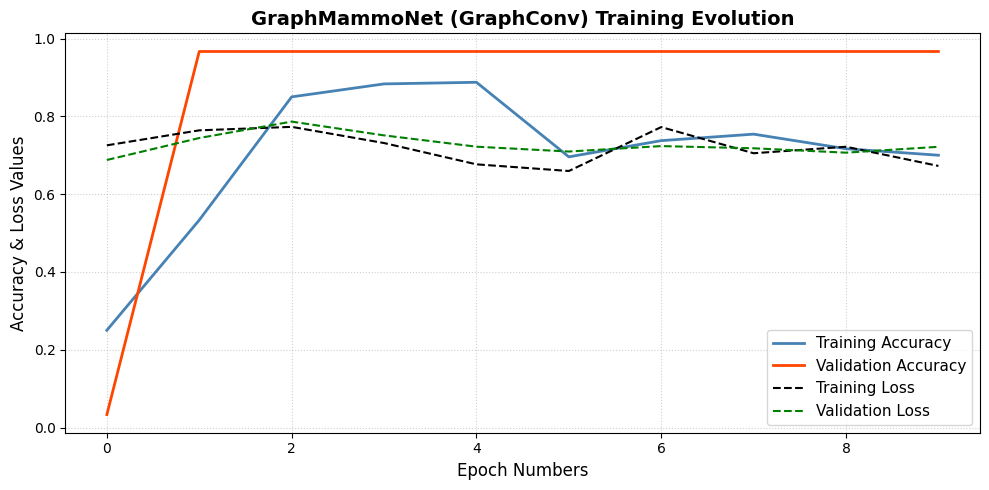

In [9]:
# Cell 9: VẼ ĐỒ THỊ HUẤN LUYỆN (Evolution Curves)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_accs, c='steelblue', label='Training Accuracy', linewidth=2)
ax.plot(val_accs, c='orangered', label='Validation Accuracy', linewidth=2)
ax.plot(train_losses, c='black', linestyle='--', label='Training Loss', linewidth=1.5)
ax.plot(val_losses, c='green', linestyle='--', label='Validation Loss', linewidth=1.5)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', fontsize=11)
ax.set_xlabel('Epoch Numbers', fontsize=12)
ax.set_ylabel('Accuracy & Loss Values', fontsize=12)
ax.set_title(f'GraphMammoNet ({LAYER_TYPE}) Training Evolution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Evolution_training.png'), dpi=200)
plt.show()


## 📤 Bước 7: Dự Đoán Tập Test & Xuất File Kaggle `submission.csv`

Theo yêu cầu của cuộc thi RSNA Screening Mammography:
* Cần gộp dự đoán theo từng bên ngực: `prediction_id = patient_id_laterality` (ví dụ: `10001_L`, `10001_R`).
* Nếu có nhiều ảnh chụp cùng một bên (ví dụ ảnh CC và MLO), lấy giá trị xác suất lớn nhất (Max-Pooling) đại diện cho bên ngực đó.
* Xuất ra file `/kaggle/working/submission.csv` gồm đúng 2 cột: `prediction_id` và `cancer`.


In [10]:
# Cell 10: DỰ ĐOÁN VÀ TẠO FILE NỘP BÀI KAGGLE (submission.csv)
test_csv_path = os.path.join(KAGGLE_DIR, 'test.csv')
test_images_dir = os.path.join(KAGGLE_DIR, 'test_images')

if os.path.exists(test_csv_path):
    df_test = pd.read_csv(test_csv_path)
else:
    print('Lưu ý: Không tìm thấy test.csv (chế độ chạy thử nghiệm). Đang tạo mẫu test giả lập.')
    df_test = pd.DataFrame({
        'site_id': [1, 1],
        'patient_id': [10001, 10001],
        'image_id': [99991, 99992],
        'laterality': ['L', 'R'],
        'view': ['CC', 'MLO'],
        'age': [55, 55],
        'cancer': [0, 0]
    })

model.eval()
test_dataset = RSNAMammogramDataset(df_test, test_images_dir, filter_func=Prewitt_v2, target_size=(256, 256))
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

records = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Kaggle Inference'):
        batch = batch.to(DEVICE)
        out = model(batch.x, batch.edge_index, batch.batch)
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        for pid, lat, prob in zip(batch.patient_id, batch.laterality, probs):
            pred_id = f'{pid}_{lat}'
            records.append({'prediction_id': pred_id, 'prob': float(prob)})

df_preds = pd.DataFrame(records)
if len(df_preds) > 0:
    df_sub = df_preds.groupby('prediction_id')['prob'].max().reset_index()
    df_sub.columns = ['prediction_id', 'cancer']
else:
    df_sub = pd.DataFrame(columns=['prediction_id', 'cancer'])

sub_path = os.path.join(OUTPUT_DIR, 'submission.csv')
df_sub.to_csv(sub_path, index=False)
print(f'\n✅ Đã lưu file nộp bài thành công: {sub_path}')
print(f'Kích thước submission: {df_sub.shape}')
print('\n5 dòng đầu tiên của submission.csv:')
print(df_sub.head())


Lưu ý: Không tìm thấy test.csv (chế độ chạy thử nghiệm). Đang tạo mẫu test giả lập.


Kaggle Inference:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Đã lưu file nộp bài thành công: /kaggle/working/submission.csv
Kích thước submission: (2, 2)

5 dòng đầu tiên của submission.csv:
  prediction_id    cancer
0       10001_L  0.450413
1       10001_R  0.450413
